# Vibration Prediction System - Example Usage

This notebook demonstrates how to use the vibration prediction system for training and evaluating LSTM models on vibration data.

## 1. Setup and Imports

In [1]:
import sys
import os
os.environ["CUDA_DEVICE_ORDER"]="PCI_BUS_ID"   # see issue #152
os.environ["CUDA_VISIBLE_DEVICES"]="3"
import json
import numpy as np
from tqdm import tqdm
import matplotlib.pyplot as plt
import torch
import yaml
import pickle
from pathlib import Path

# Add project to path
project_root = Path.cwd()
sys.path.append(str(project_root))

# Import project modules
from data.dataset import VibrationDataset, create_dataloaders, load_and_split_data
from models.lstm_predictor import LSTMPredictor
from training.trainer import Trainer
from utils.visualization import VibrationVisualizer, VibrationVisualizer2
from utils.signal_processing import compute_spectral_features, detect_bifurcation_points

# Set random seeds for reproducibility
torch.manual_seed(42)
np.random.seed(42)

print("Setup complete!")

Setup complete!


## 2. Load Configuration

In [2]:
# Load configuration files
with open('config/base_config.yaml', 'r') as f:
    base_config = yaml.safe_load(f)

with open('config/lstm_config.yaml', 'r') as f:
    lstm_config = yaml.safe_load(f)

# Merge configurations
config = base_config.copy()
for key, value in lstm_config.items():
    if key in config and isinstance(config[key], dict) and isinstance(value, dict):
        config[key].update(value)
    else:
        config[key] = value

print("Configuration loaded:")
print(f"- Window size: {config['data']['window_size']}")
print(f"- Prediction horizon: {config['data']['prediction_horizon']}")
print(f"- Model type: {config['model']['type']}")
print(f"- Hidden size: {config['model']['hidden_size']}")

Configuration loaded:
- Window size: 1000
- Prediction horizon: 200
- Model type: lstm
- Hidden size: 256


In [3]:
config

{'data': {'window_size': 1000,
  'prediction_horizon': 200,
  'stride': 100,
  'sampling_rate': 10,
  'train_split': 0.7,
  'val_split': 0.15,
  'test_split': 0.15,
  'dataset_path': 'project/create_datasets/datasets',
  'dataset_name': 'mathieu_delayed_dataset.pkl'},
 'features': {'window_sizes': [10, 50, 100]},
 'training': {'batch_size': 64,
  'learning_rate': 0.0005,
  'epochs': 100,
  'early_stopping_patience': 15,
  'gradient_clipping': 1.0,
  'optimizer': 'adam',
  'scheduler': 'reduce_lr_on_plateau',
  'scheduled_sampling': {'enabled': True,
   'initial_ratio': 1.0,
   'decay_rate': 0.98,
   'min_ratio': 0.1},
  'weight_decay': '1e-5',
  'scheduler_patience': 10,
  'scheduler_factor': 0.5},
 'augmentation': {'noise_level': 0.01,
  'time_warping': True,
  'parameter_interpolation': True,
  'enabled': False},
 'model': {'hidden_size': 256,
  'num_layers': 2,
  'dropout': 0.3,
  'recurrent_dropout': 0.3,
  'teacher_forcing_noise_std': 0.0,
  'type': 'lstm',
  'bidirectional': Fals

## 3. Load and Explore Dataset

In [4]:
# Create dataset
dataset_config = {
    'data_path': 'create_datasets/datasets/mathieu_delayed_dataset_shrink.pkl',
    'window_size': 1500,
    'prediction_horizon': 1500,
    'stride': 500,
    'sampling_rate': 5,
    'normalization': None,
    'train_split': 0.7,
    'val_split': 0.10,
    'test_split': 0.20,
    'random_seed': config['random_seed']
}
dataset_config["max_samples_for_scaling"] = 2
dataset_config["rm_start_t"] = 500
dataset_config["window_normalization"] = "z_score"
dataset_config["calc_max_diff"] = True
dataset_config["balance_by_diff"] = True
dataset_config["balance_type"] = "equal_width"
# dataset_config["diff_quantiles"] = [0., 0.5, 0.75, 0.9, 0.95, 1]
dataset_config["diff_quantiles"] = list(np.linspace(0, 1, 10))

In [ ]:
train_trajectories, val_trajectories, test_trajectories = load_and_split_data(dataset_config)

print(json.dumps(dataset_config, indent=2))
# Create train dataset to explore
train_dataset = VibrationDataset(train_trajectories, **dataset_config)

print(f"Dataset loaded:")
print(f"- Total sequences: {len(train_dataset)}")

# Get a sample
sample = train_dataset[0]
print(f"\nSample shapes:")
print(f"- Features: {sample['features'].shape}")
# print(f"- Parameters: {sample['parameters'].shape}")
print(f"- Targets: {sample['targets'].shape}")
# print(f"- Max amplitude: {sample['max_amplitude'].item():.4f}")

{
  "data_path": "create_datasets/datasets/mathieu_delayed_dataset_shrink.pkl",
  "window_size": 1500,
  "prediction_horizon": 1500,
  "stride": 500,
  "sampling_rate": 5,
  "normalization": null,
  "train_split": 0.7,
  "val_split": 0.15,
  "test_split": 0.15,
  "random_seed": 42,
  "max_samples_for_scaling": 2,
  "rm_start_t": 500,
  "window_normalization": "z_score",
  "calc_max_diff": true,
  "balance_by_diff": true,
  "balance_type": "equal_width",
  "diff_quantiles": [
    0.0,
    0.1111111111111111,
    0.2222222222222222,
    0.3333333333333333,
    0.4444444444444444,
    0.5555555555555556,
    0.6666666666666666,
    0.7777777777777777,
    0.8888888888888888,
    1.0
  ]
}


100%|██████████| 1399/1399 [00:09<00:00, 140.77it/s]


Sequence creation took 9.94 seconds
54561 sequences created
Dataset initialized: 54561 sequences in 10.10 seconds
Dataset loaded:
- Total sequences: 54561

Sample shapes:
- Features: torch.Size([1500, 2])
- Targets: torch.Size([1500, 2])


## 4. Visualize Sample Data

In [7]:
# Create visualizer
visualizer = VibrationVisualizer(width=1200, height=300)
i = 3
# Get sample data
sample = train_dataset[i]
features = sample['features'].numpy()
targets = sample['targets'].numpy()

max_f = features[:, 0].max()
max_t = targets[:, 0].max()
print(max_t - max_f)

std = np.std(targets, axis=0)
print(std)
# Plot trajectory comparison (using features as input, targets as ground truth)
fig = visualizer.plot_trajectory_comparison(
    input_data=features,
    target_data=targets + np.random.normal(0, std * 0.03, sample['targets'].shape),
    predicted_data=targets,  # Using targets as "prediction" for visualization
    feature_names=['Position', 'Velocity'],
    title='Sample Vibration Trajectory'
)
fig.show()

0.9322817
[0.72089994 1.5276692 ]


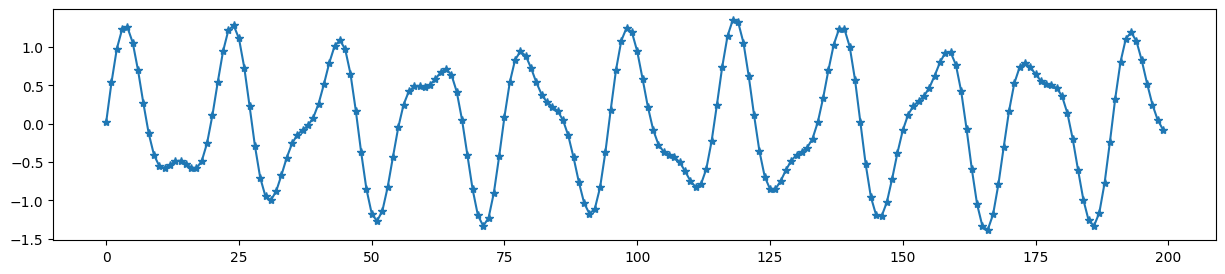

In [11]:
plt.figure(figsize=(15, 3))
plt.plot(np.arange(len(features[:200, 0])), features[:200, 0], "-*")

(1500, 1500)

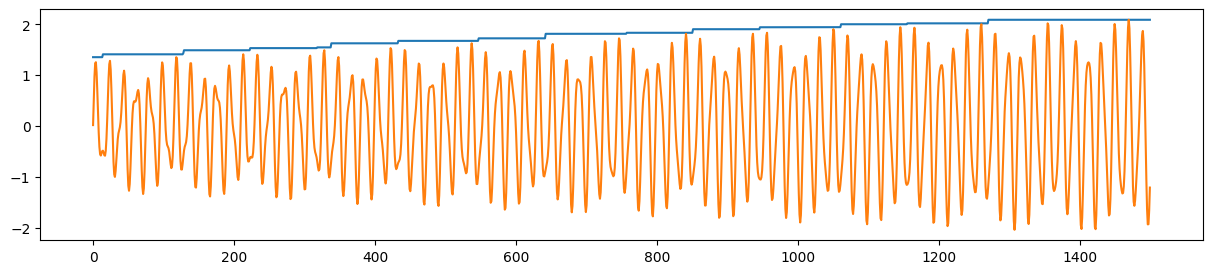

In [12]:
from scipy.ndimage import maximum_filter1d

x = features[:, 0]
envelope = maximum_filter1d(x, size=400)
plt.figure(figsize=(15, 3))
plt.plot(envelope)
plt.plot(x)
len(envelope), len(x)

(np.float32(0.4129505), np.float32(0.4129505), np.float64(0.4129504670198566))

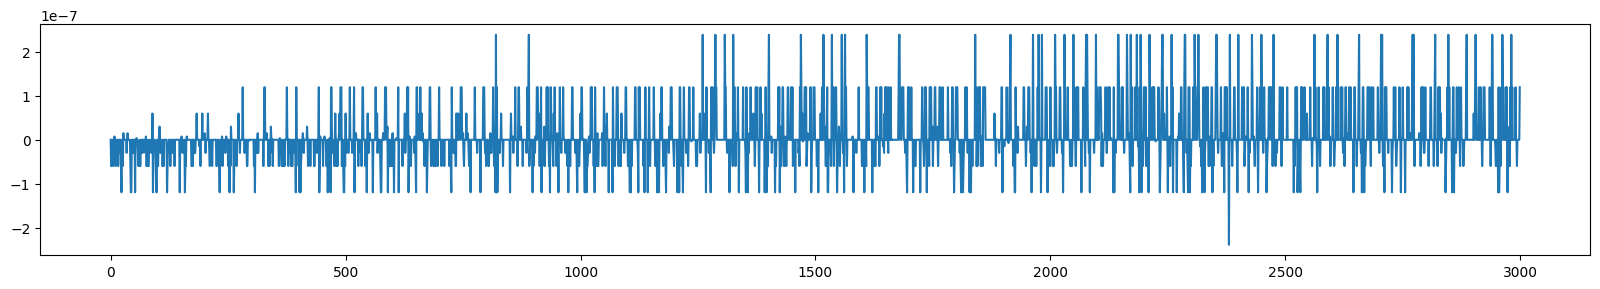

In [14]:
features = sample['features'].numpy()[:, :1]
targets = sample['targets'].numpy()[:, :1]

features_norm = sample['features_norm'].numpy()[:, :1]
targets_norm = sample['targets_norm'].numpy()[:, :1]

scaler = StandardScaler().fit(features)
features = scaler.transform(features)
targets = scaler.transform(targets)


envelope = maximum_filter1d(np.concatenate([features, targets], axis=0).reshape(-1), size=400)
envelope2 = maximum_filter1d(np.concatenate([features_norm, targets_norm], axis=0).reshape(-1), size=400)
diff = (np.max(envelope) - np.min(envelope)) / (np.max(envelope))
diff2 = (np.max(envelope2) - np.min(envelope2)) / (np.max(envelope2))
plt.figure(figsize=(20, 3))
# plt.plot(envelope)
# plt.plot(np.concatenate([features, targets]))
# plt.plot(np.concatenate([features_norm, targets_norm]))
plt.plot(np.concatenate([features, targets], axis=0).reshape(-1) - np.concatenate([features_norm, targets_norm], axis=0).reshape(-1))
diff, diff2, sample['diff']

In [10]:
diffs = []
for sample in tqdm(train_dataset):
    # features = sample['features'].numpy()
    # targets = sample['targets'].numpy()

    # scaler = StandardScaler().fit(features)
    # features = scaler.transform(features)[:, 0]
    # targets = scaler.transform(targets)[:, 0]
    # envelope = maximum_filter1d(np.concatenate([features, targets], axis=0), size=400)
    # diff = (np.max(envelope) - np.min(envelope)) / (np.max(envelope))
    diff = sample['diff']
    diffs.append(diff)
np.mean(diffs)


100%|██████████| 54561/54561 [00:07<00:00, 7136.63it/s]


np.float64(0.4466872722618165)

In [11]:
diffs = np.array(diffs)

0.4474441450853173

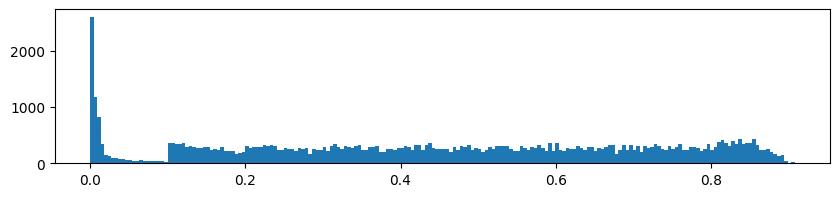

In [12]:
plt.figure(figsize=(10, 2))
plt.hist(diffs, bins=200);
len(diffs[diffs > 0.5]) / len(diffs)

In [13]:
len(diffs[diffs > 0.61]) / len(diffs)

0.32695515111526546

In [14]:
for quant in [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95]:
    print(quant, np.quantile(diffs, quant))


0.1 0.039207832396232406
0.2 0.1725709226573116
0.3 0.2689770355858733
0.4 0.3606469406093471
0.5 0.45113946161323937
0.6 0.543466100597745
0.7 0.6348074238967629
0.8 0.7267025869308734
0.9 0.8133145358974143
0.95 0.8465437756959424


In [15]:
np.quantile(diffs, [0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 0.95])

array([0.03920783, 0.17257092, 0.26897704, 0.36064694, 0.45113946,
       0.5434661 , 0.63480742, 0.72670259, 0.81331454, 0.84654378])

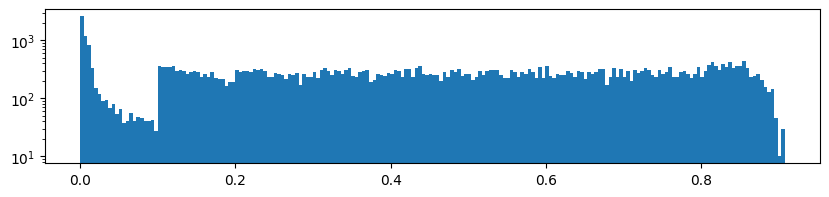

In [16]:
plt.figure(figsize=(10, 2))
plt.hist(diffs, bins=200);
len(diffs[diffs > 0.5]) / len(diffs)
plt.yscale('log')

In [22]:
for sample in tqdm(train_dataset):
    features = sample['features'].numpy()
    targets = sample['targets'].numpy()

    scaler = StandardScaler().fit(features)
    features = scaler.transform(features)[:, 0]
    targets = scaler.transform(targets)[:, 0]
    envelope = maximum_filter1d(np.concatenate([features, targets], axis=0), size=400)
    diff = (np.max(envelope) - np.min(envelope)) / (np.max(envelope))
    if diff > 0.30 and diff < 0.9:
        print(diff)
        break


  0%|          | 0/54599 [00:00<?, ?it/s]

0.5466649


np.float32(0.5466649)

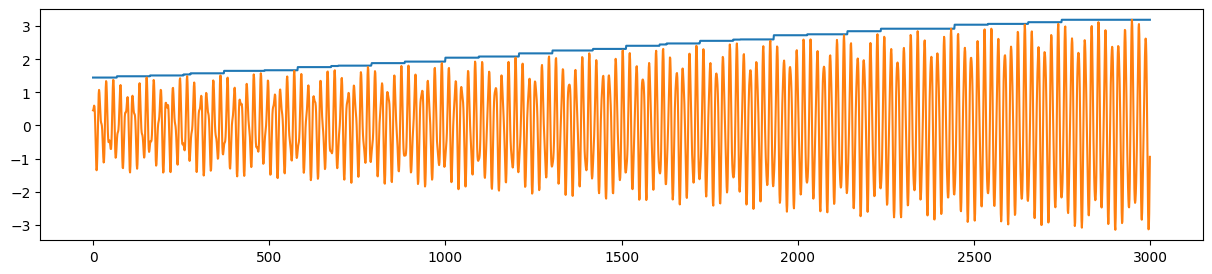

In [23]:
plt.figure(figsize=(15, 3))
plt.plot(envelope)
plt.plot(np.concatenate([features, targets]))
diff

## 6. Create Data Loaders

In [5]:
train_trajectories, val_trajectories, test_trajectories = load_and_split_data(dataset_config)

# Create datasets
train_dataset = VibrationDataset(train_trajectories, **dataset_config)
val_dataset = VibrationDataset(val_trajectories, **dataset_config)
test_dataset = VibrationDataset(test_trajectories, **dataset_config)

# Create data loaders
batch_size = 128
train_loader = create_dataloaders(
    train_dataset,
    batch_size=batch_size,
    num_workers=2,  # Reduce for notebook
    shuffle=True
)
val_loader = create_dataloaders(
    val_dataset,
    batch_size=batch_size,
    num_workers=2,
    shuffle=False
)
test_loader = create_dataloaders(
    test_dataset,
    batch_size=batch_size,
    num_workers=2,
    shuffle=False
)

print(f"Data loaders created:")
print(f"- Train batches: {len(train_loader)}")
print(f"- Validation batches: {len(val_loader)}")
print(f"- Test batches: {len(test_loader)}")

# Check a batch
batch = next(iter(train_loader))
print(f"\nBatch shapes:")
for key, value in batch.items():
    if isinstance(value, torch.Tensor):
        print(f"- {key}: {value.shape}")
    else:
        print(f"- {key}: {type(value)}")

100%|██████████| 1399/1399 [00:10<00:00, 136.27it/s]


Sequence creation took 10.27 seconds
54561 sequences created
Dataset initialized: 54561 sequences in 10.41 seconds


100%|██████████| 200/200 [00:01<00:00, 137.73it/s]


Sequence creation took 1.46 seconds
7800 sequences created
Dataset initialized: 7800 sequences in 1.48 seconds


100%|██████████| 401/401 [00:02<00:00, 160.97it/s]


Sequence creation took 2.49 seconds
15639 sequences created
Dataset initialized: 15639 sequences in 2.54 seconds
Data loaders created:
- Train batches: 427
- Validation batches: 61
- Test batches: 123

Batch shapes:
- features: torch.Size([128, 1500, 2])
- features_norm: torch.Size([128, 1500, 2])
- targets: torch.Size([128, 1500, 2])
- targets_norm: torch.Size([128, 1500, 2])
- diff: torch.Size([128])
- trajectory_id: torch.Size([128])


## 7. Create and Initialize Model

In [7]:
# Setup model configuration
model_config = config['model'].copy()
model_config['input_size'] = 2  # x, x_dot
model_config['output_size'] = 2  # x
# model_config['hidden_size'] = 64
model_config['hidden_size'] = 128
# model_config['num_layers'] = 5
model_config['num_layers'] = 2
# model_config['dropout'] = 0.1
# model_config['recurrent_dropout'] = 0.1
model_config['dropout'] = 0.1
model_config['recurrent_dropout'] = 0.0
model_config['output_layers'] = [64]
model_config['output_activation'] = None
# model_config['teacher_forcing_noise_std'] = 0.02
model_config['teacher_forcing_noise_std'] = 0.02

# Create model
model = LSTMPredictor(model_config)

# Print model info
model_info = model.get_model_info()
print(f"Model Information:")
print(f"- Type: {model_info['model_type']}")
print(f"- Total parameters: {model_info['total_parameters']:,}")
print(f"- Trainable parameters: {model_info['trainable_parameters']:,}")

# Test forward pass
device = 'cuda' if torch.cuda.is_available() else 'cpu'
model = model.to(device)

# Move batch to device
batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v for k, v in batch.items()}

# Forward pass
with torch.no_grad():
    outputs = model(batch)

print(f"\nModel outputs:")
for key, value in outputs.items():
    if isinstance(value, torch.Tensor):
        print(f"- {key}: {value.shape}")

print(f"\nUsing device: {device}")

Model Information:
- Type: lstm
- Total parameters: 273,090
- Trainable parameters: 273,090

Model outputs:
- trajectory: torch.Size([128, 3000, 2])
- hidden_state: torch.Size([2, 128, 128])
- cell_state: torch.Size([2, 128, 128])
- lstm_output: torch.Size([128, 3000, 128])

Using device: cuda


In [8]:
model_config

{'hidden_size': 128,
 'num_layers': 2,
 'dropout': 0.1,
 'recurrent_dropout': 0.0,
 'teacher_forcing_noise_std': 0.02,
 'type': 'lstm',
 'bidirectional': False,
 'input_normalization': 'z_score',
 'output_layers': [64],
 'output_activation': None,
 'input_size': 2,
 'output_size': 2}

## 8. Train Model (Short Demo)

In [ ]:
# Create a short training configuration for demo
# torch.autograd.set_detect_anomaly(True)

demo_config = config['training'].copy()
demo_config['epochs'] = 100  # Short demo
demo_config['log_interval'] = 1
demo_config['optimizer'] = 'adamw'
demo_config['early_stopping_patience'] = 10
demo_config['output_dir'] = 'demo_outputs'
demo_config['augmentation'] = {'enabled': False}
demo_config['pretrain_val'] = True
demo_config['scheduled_sampling'] = {
    "enabled": False
}
# demo_config['scheduler'] = "steplr"
demo_config['scheduler'] = "reduce_lr_on_plateau"
# demo_config['scheduler_patience'] = 3
demo_config['scheduler_patience'] = 3
demo_config['scheduler_factor'] = 0.5
# demo_config['learning_rate'] = 0.0001
demo_config['learning_rate'] = 0.0005
demo_config['weight_decay'] = 1e-5
demo_config["loss"] = {'weights': {'trajectory': 1, 'amplitude': 1}}

dt = 1 / 5
# Create trainer
trainer = Trainer(
    model=model,
    train_loader=train_loader,
    val_loader=val_loader,
    config=demo_config,
    device=device,
    const_parameters={"dt": dt},
    checkpoint_folder="model_180226",
    checkpoint_interval=2,
)

print("Starting demo training (5 epochs)...")

# Train for a few epochs
results = trainer.train()

print(f"\nDemo training completed!")
print(f"- Best validation loss: {results['best_val_loss']:.6f}")
print(f"- Training time: {results['training_time']:.2f} seconds")
print(f"- Total epochs: {results['total_epochs']}")

adamw
Starting demo training (5 epochs)...


Validation: 100%|██████████| 61/61 [00:03<00:00, 18.65it/s]


loss: 5.2533
loss_components.trajectory: 3.0079
loss_components.amplitude: 2.2454
rmse_overall: 1.7333
mae_overall: 1.3605
r2_overall: -0.1481
rmse_position: 1.8851
mae_position: 1.4557
r2_position: -0.1330
rmse_velocity: 1.5667
mae_velocity: 1.2653
r2_velocity: -0.1707
rmse_horizon_10: 1.3333
mae_horizon_10: 1.1129
rmse_horizon_50: 1.3336
mae_horizon_50: 1.1107
rmse_horizon_100: 1.3422
mae_horizon_100: 1.1162


Epoch 0 (TF: 1.000, LR: 0.000500):  30%|███       | 129/427 [00:11<00:25, 11.54it/s, loss=0.3312, avg_loss=0.6909, TF_ratio=1.000, LR=0.000500]


KeyboardInterrupt: 

In [17]:
torch.save(model, "model_1.pth")

In [137]:
new_lr = 0.0001
for param_group in trainer.optimizer.param_groups:
    param_group['lr'] = new_lr
trainer.early_stopping_patience = 50
results = trainer.train()

KeyboardInterrupt: 

In [18]:
torch.save(model, "model_2.pth")

In [ ]:
Epoch  14: Train Loss: 0.000563, Val Loss: 0.000446

In [44]:
trainer.training_history["step_losses"][0], trainer.training_history["step_loss_components"]["physics"][0], trainer.training_history["step_loss_components"]["trajectory"][0]

IndexError: list index out of range

In [ ]:
new_lr = 0.00005
for param_group in trainer.optimizer.param_groups:
    param_group['lr'] = new_lr

In [58]:
for param_group in trainer.optimizer.param_groups:
    print(param_group['lr'])

3.125e-05


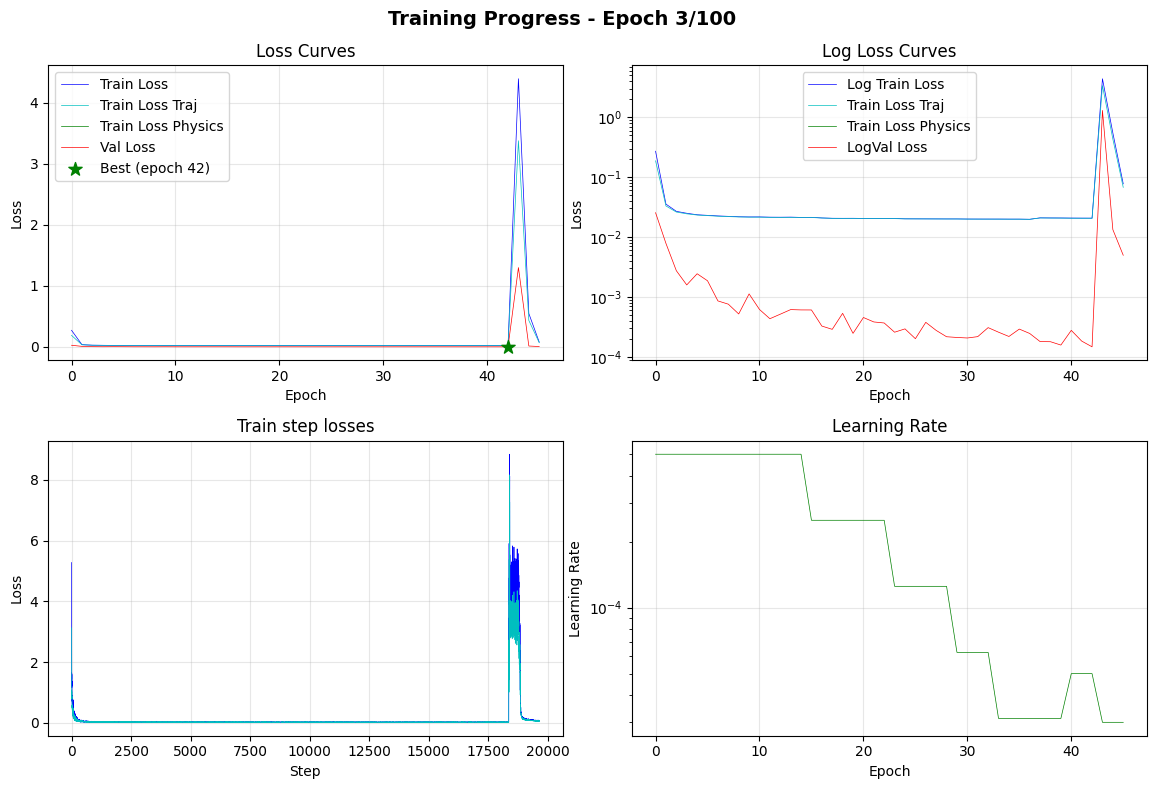

Epoch   2: Train Loss: 0.077286, Val Loss: 0.004963, LR: 3.00e-05, TF Ratio: 0.100

Epoch 2 Detailed Metrics:
----------------------------------------
loss                : Train: 0.077286, Val: 0.004963
loss_components.trajectory          : Train: 0.067491, Val: 0.004198
loss_components.amplitude           : Train: 0.009795, Val: 0.000766
rmse_overall        : Train: 0.259218, Val: 0.064754
mae_overall         : Train: 0.184995, Val: 0.047739
r2_overall          : Train: 0.975550, Val: 0.998464
rmse_position       : Train: 0.276004, Val: 0.063268
mae_position        : Train: 0.195829, Val: 0.047177
r2_position         : Train: 0.977129, Val: 0.998790
rmse_velocity       : Train: 0.241199, Val: 0.066195
mae_velocity        : Train: 0.174161, Val: 0.048302
r2_velocity         : Train: 0.973110, Val: 0.997963
rmse_horizon_10     : Train: 0.132925, Val: 0.050850
mae_horizon_10      : Train: 0.102561, Val: 0.038604
rmse_horizon_50     : Train: 0.153379, Val: 0.051004
mae_horizon_50      : 

Validation: 100%|██████████| 92/92 [00:04<00:00, 20.50it/s]



TRAINING COMPLETED
Best Validation Loss: 0.000147
Total Epochs: 3

VIBRATION PREDICTION METRICS SUMMARY
RMSE                : 0.064754
MAE                 : 0.047739
R²                  : 0.998464


{'best_val_loss': 0.00014707732019735926,
 'final_metrics': {'loss': 0.004963476484155525,
  'loss_components': {'trajectory': 0.004197769942592182,
   'amplitude': 0.0007657065111941293},
  'rmse_overall': np.float64(0.06475416595475234),
  'mae_overall': np.float64(0.04773944369314805),
  'r2_overall': np.float64(0.9984643381574879),
  'rmse_position': np.float64(0.0632682774028518),
  'mae_position': np.float64(0.04717661999166012),
  'r2_position': np.float64(0.9987895611835562),
  'rmse_velocity': np.float64(0.06619461999642944),
  'mae_velocity': np.float64(0.048302269095311996),
  'r2_velocity': np.float64(0.9979626257782397),
  'rmse_horizon_10': np.float64(0.05085029025779914),
  'mae_horizon_10': np.float64(0.03860385258398626),
  'rmse_horizon_50': np.float64(0.051004457273398744),
  'mae_horizon_50': np.float64(0.03878261468818654),
  'rmse_horizon_100': np.float64(0.05107457126458209),
  'mae_horizon_100': np.float64(0.0388761227140608)},
 'training_time': 4333.98936009407

In [73]:
new_lr = 0.00003
for param_group in trainer.optimizer.param_groups:
    param_group['lr'] = new_lr

trainer.use_scheduled_sampling = True
trainer.current_teacher_forcing_ratio = 0.
trainer.early_stopping_patience = 3
trainer.train()

In [ ]:
torch.save(model, "model_6.pth")

In [10]:
model = torch.load("model_6.pth", weights_only=False)

In [ ]:
Train Loss: 0.019798, Val Loss: 0.000246

SyntaxError: invalid syntax (2895102804.py, line 1)

In [35]:
# from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# all_predictions = np.concatenate(trainer.train_metrics.predictions, axis=0)
# all_targets = np.concatenate(trainer.train_metrics.targets, axis=0)

# metrics = {}

# # Overall metrics
# metrics['rmse_overall'] = np.sqrt(mean_squared_error(
#     all_targets.reshape(-1),
#     all_predictions.reshape(-1)
# ))

## 9. Evaluate Model Performance

In [11]:
# Evaluate on test set
from training.metrics import VibrationMetrics

model.eval()
metrics = VibrationMetrics()

all_predictions = []
all_targets = []
all_features = []
all_amplitudes_pred = []
all_amplitudes_true = []

print("Evaluating model on test set...")

with torch.no_grad():
    # for i, batch in enumerate(test_loader):
    for i, batch in enumerate(train_loader):
        if i >= 10:  # Limit for demo
            break

        # Move to device
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in batch.items()}
        features = batch["features_norm"]
        targets = batch["targets_norm"]
        batch_size, seq_len, _ = features.shape
        batch_size, horizon_len, _ = targets.shape

        # Forward pass
        outputs = model(batch)

        predictions = outputs["trajectory"][:, seq_len - 1:-1, :]
        targets = batch["targets_norm"][:,:,:]

        # Collect results
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        all_features.append(features.cpu().numpy())

        if 'amplitude' in outputs:
            all_amplitudes_pred.append(outputs['amplitude'].cpu().numpy())
        if 'max_amplitude' in batch:
            all_amplitudes_true.append(batch['max_amplitude'].cpu().numpy())

        # Update metrics
        metrics.update(
            predictions=predictions,
            targets=targets,
            amplitudes_pred=outputs.get('amplitude'),
            amplitudes_true=batch.get('max_amplitude')
        )
predictions = np.concatenate(all_predictions, axis=0)
targets = np.concatenate(all_targets, axis=0)
features = np.concatenate(all_features, axis=0)

# Compute metrics
evaluation_results = metrics.compute_all_metrics()

# Print summary
print("\nEvaluation Results:")
summary = metrics.get_summary_metrics()
for metric_name, value in summary.items():
    print(f"- {metric_name}: {value:.6f}")

Evaluating model on test set...

Evaluation Results:
- RMSE: 0.064064
- MAE: 0.047250
- R²: 0.998501


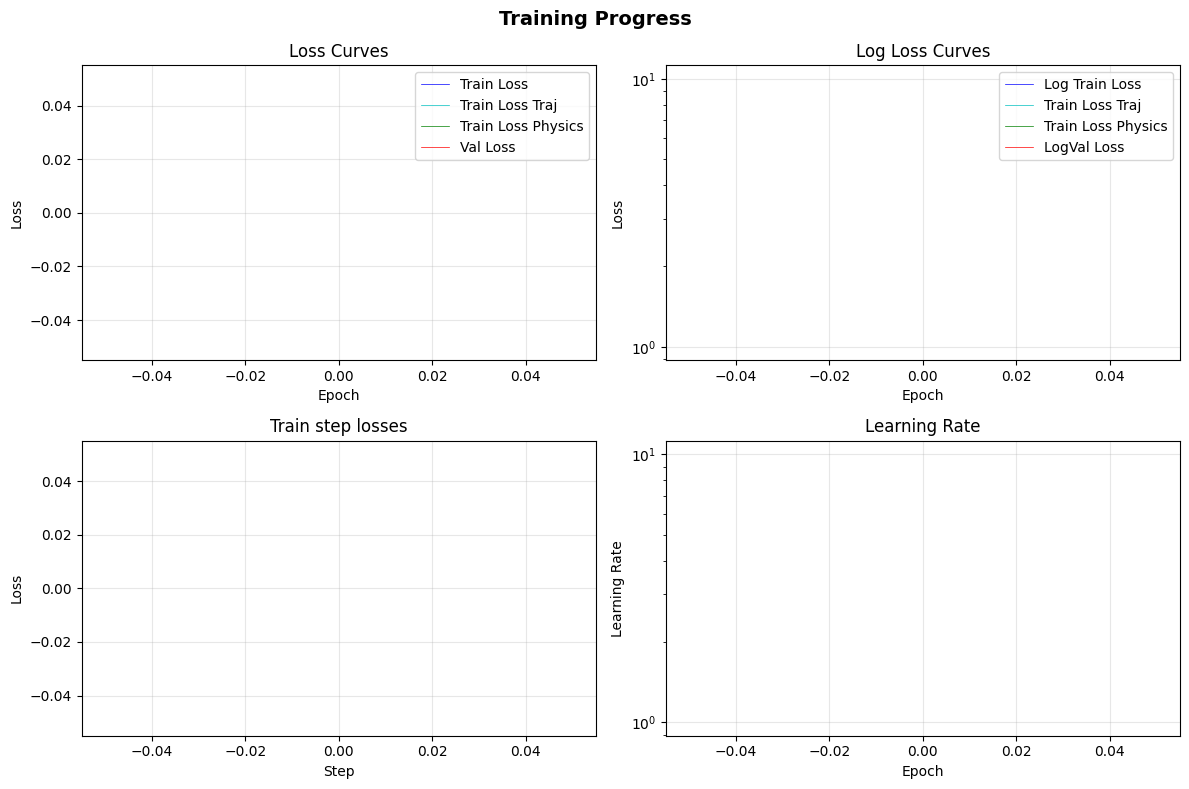

In [12]:
plt.show();

## 10. Visualize Predictions

In [13]:
# Concatenate results for visualization
visualizer = VibrationVisualizer2(figsize=(1000, 400))

# Plot sample predictions
n_samples = min(10, len(predictions))
di = 0

for i in range(n_samples):
    # Create dummy input (use first part of target)
    input_data = features[i+di, :, 0:1]
    target_data = targets[i+di, :, 0:1]
    predicted_data = predictions[i+di, :, 0:1]

    fig = visualizer.plot_trajectory_comparison(
        input_data,
        target_data,
        predicted_data,
        title=f'Sample {i+1} - Prediction vs Ground Truth'
    )
    plt.show()

In [14]:
x = batch['features_norm']
x.shape

torch.Size([128, 1500, 2])

In [16]:
# Evaluate on test set
from training.metrics import VibrationMetrics

model.eval()
metrics = VibrationMetrics()

all_predictions = []
all_targets = []
all_features = []
all_amplitudes_pred = []
all_amplitudes_true = []

print("Evaluating model on test set...")

from collections import defaultdict
total_loss = 0.0
total_samples = 0
total_batches = 0
total_loss_components = defaultdict(float)

with torch.no_grad():
    # for i, batch in enumerate(test_loader):
    for i, batch in enumerate(train_loader):
        print(i)
        if i >= 5:  # Limit for demo
            break

        # Move to device
        batch = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in batch.items()}
        features = batch["features_norm"]
        targets = batch["targets_norm"]
        batch_size, seq_len, _ = features.shape
        batch_size, horizon_len, _ = targets.shape


        # Forward pass
        trajectory_pred = model.predict_trajectory(batch, horizon=horizon_len, std_target=None)

        # predictions = outputs["trajectory"][:, seq_len - 1:-1, :]
        predictions = trajectory_pred
        targets = batch["targets_norm"][:,:,:]

        loss, losses = trainer.criterion(
            predictions,
            targets,
            trainer.const_parameters
        )
        total_loss += loss.item()
        total_batches += 1
        for name, val in losses.items():
            total_loss_components[name] += val.item()

        # Collect results
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        all_features.append(features.cpu().numpy())

        # Update metrics
        metrics.update(
            predictions=predictions,
            targets=targets,
            amplitudes_pred=outputs.get('amplitude'),
            amplitudes_true=batch.get('max_amplitude')
        )
predictions = np.concatenate(all_predictions, axis=0)
targets = np.concatenate(all_targets, axis=0)
features = np.concatenate(all_features, axis=0)

# Compute metrics
evaluation_results = metrics.compute_all_metrics()

# Print summary
print("\nEvaluation Results:")
summary = metrics.get_summary_metrics()
for metric_name, value in summary.items():
    print(f"- {metric_name}: {value:.6f}")

avg_loss = total_loss / total_batches
avg_loss_components = {k: v / total_batches for k, v in total_loss_components.items()}

print(f"Average loss: {avg_loss:.6f}")
print(f"Average loss components: {avg_loss_components}")


Evaluating model on test set...
0
1
2
3
4
5

Evaluation Results:
- RMSE: 1.370405
- MAE: 0.787563
- R²: 0.364481
Average loss: 2.289424
Average loss components: {'trajectory': 1.8864076852798461, 'amplitude': 0.403016471862793}


In [17]:
# Evaluation Results:
# - RMSE: 0.315044
# - MAE: 0.171970
# - R²: 0.973673

In [19]:
# Concatenate results for visualization
visualizer = VibrationVisualizer2(figsize=(1000, 400))

# Plot sample predictions
n_samples = min(10, len(predictions))
di = 100

for i in range(n_samples):
    # Create dummy input (use first part of target)
    input_data = features[i+di, :, 0:1]
    target_data = targets[i+di, :, 0:1]
    predicted_data = predictions[i+di, :, 0:1]

    fig = visualizer.plot_trajectory_comparison(
        input_data,
        np.concatenate([target_data, np.zeros((predicted_data.shape[0] - target_data.shape[0], target_data.shape[1]))]),
        predicted_data,
        title=f'Sample {i+1} - Prediction vs Ground Truth'
    )
    plt.show()


In [23]:
train_dataset[0]["features_norm"].unsqueeze(0).shape

torch.Size([1, 1500, 2])

In [21]:
batch["features_norm"].shape

torch.Size([128, 1500, 2])

In [26]:
data

{'features': tensor([[-0.6068,  2.3411],
         [-0.0833,  2.7736],
         [ 0.4525,  2.4614],
         ...,
         [-2.0129, -1.1774],
         [-2.0868,  0.3802],
         [-1.8926,  1.4670]], device='cuda:0'),
 'features_norm': tensor([[-0.5961,  1.1685],
         [-0.0822,  1.3841],
         [ 0.4438,  1.2285],
         ...,
         [-1.9763, -0.5854],
         [-2.0489,  0.1910],
         [-1.8583,  0.7328]], device='cuda:0'),
 'targets': tensor([[-1.5393,  1.9712],
         [-1.1368,  1.9910],
         [-0.7591,  1.7699],
         ...,
         [-0.1455, -3.8377],
         [-0.9487, -4.1666],
         [-1.7915, -4.1851]], device='cuda:0'),
 'targets_norm': tensor([[-1.5115,  0.9841],
         [-1.1163,  0.9940],
         [-0.7456,  0.8838],
         ...,
         [-0.1432, -1.9115],
         [-0.9317, -2.0755],
         [-1.7590, -2.0847]], device='cuda:0'),
 'diff': np.float64(0.6724359494921698),
 'trajectory_id': 488}

In [49]:
# Evaluate on test set
from training.metrics import VibrationMetrics

data = train_dataset[100]
data = {k: v.unsqueeze(0) if isinstance(v, torch.Tensor) else v
                for k, v in data.items()}

model.eval()
metrics = VibrationMetrics()

all_predictions = []
all_targets = []
all_features = []
all_amplitudes_pred = []
all_amplitudes_true = []

print("Evaluating model on test set...")

from collections import defaultdict
total_loss = 0.0
total_samples = 0
total_batches = 0
total_loss_components = defaultdict(float)

with torch.no_grad():
    # for i, batch in enumerate(test_loader):
    for i in range(5):
        print(i)

        # Move to device
        data = {k: v.to(device) if isinstance(v, torch.Tensor) else v
                for k, v in data.items()}
        features = data["features_norm"]
        targets = data["targets_norm"]
        batch_size, seq_len, _ = features.shape
        batch_size, horizon_len, _ = targets.shape

        # Forward pass
        trajectory_pred = model.predict_trajectory(data, horizon=horizon_len, std_target=0.2)

        # predictions = outputs["trajectory"][:, seq_len - 1:-1, :]
        predictions = trajectory_pred
        targets = data["targets_norm"]

        loss, losses = trainer.criterion(
            predictions,
            targets,
            trainer.const_parameters
        )
        total_loss += loss.item()
        total_batches += 1
        for name, val in losses.items():
            total_loss_components[name] += val.item()

        # Collect results
        all_predictions.append(predictions.cpu().numpy())
        all_targets.append(targets.cpu().numpy())
        all_features.append(features.cpu().numpy())

        # Update metrics
        metrics.update(
            predictions=predictions,
            targets=targets,
        )
predictions = np.concatenate(all_predictions, axis=0)
targets = np.concatenate(all_targets, axis=0)
features = np.concatenate(all_features, axis=0)

# Compute metrics
evaluation_results = metrics.compute_all_metrics()

# Print summary
print("\nEvaluation Results:")
summary = metrics.get_summary_metrics()
for metric_name, value in summary.items():
    print(f"- {metric_name}: {value:.6f}")

avg_loss = total_loss / total_batches
avg_loss_components = {k: v / total_batches for k, v in total_loss_components.items()}

print(f"Average loss: {avg_loss:.6f}")
print(f"Average loss components: {avg_loss_components}")


Evaluating model on test set...
0
1
2
3
4

Evaluation Results:
- RMSE: 0.578353
- MAE: 0.463282
- R²: 0.629506
Average loss: 0.367595
Average loss components: {'trajectory': 0.33469106554985045, 'amplitude': 0.032904145494103434}


In [50]:
predictions[0]

array([[ 0.3639315 , -1.8381811 ],
       [-0.5422298 , -1.7105968 ],
       [-1.2181268 , -1.2080523 ],
       ...,
       [ 0.6522064 ,  0.6019737 ],
       [ 0.75857997,  0.03113138],
       [ 0.58066833, -0.32675025]], dtype=float32)

In [51]:
predictions[1]

array([[ 3.6393151e-01, -1.8381811e+00],
       [-6.0635108e-01, -1.6956534e+00],
       [-1.2684430e+00, -1.1720434e+00],
       ...,
       [ 7.0740449e-01,  5.8075774e-01],
       [ 8.0181491e-01,  7.7200588e-04],
       [ 6.0951835e-01, -3.5440773e-01]], dtype=float32)

In [52]:
# Concatenate results for visualization
visualizer = VibrationVisualizer2(figsize=(1000, 400))

# Plot sample predictions
n_samples = min(10, len(predictions))
di = 0

for i in range(n_samples):
    # Create dummy input (use first part of target)
    input_data = features[i+di, :, 0:1]
    target_data = targets[i+di, :, 0:1]
    predicted_data = predictions[i+di, :, 0:1]

    fig = visualizer.plot_trajectory_comparison(
        input_data,
        np.concatenate([target_data, np.zeros((predicted_data.shape[0] - target_data.shape[0], target_data.shape[1]))]),
        predicted_data,
        title=f'Sample {i+1} - Prediction vs Ground Truth'
    )
    plt.show()
